# Analisis EDA & Forecasting
# Nilai Tukar Petani (NTP) Provinsi Jawa Tengah 2019–2026

## - Kartika Nur Savira
## - Diyanti Pratiwi

> **Sumber data:** BPS Jawa Tengah  
> **Periode:** Januari 2019 – April 2026  

Link Dataset : https://docs.google.com/spreadsheets/d/1ymUQBYxG0UYjPMcCLCd352-P6trCmFS7/edit?usp=sharing&ouid=103327432944460170481&rtpof=true&sd=true

## Install & Import Library

In [ ]:
!pip install pmdarima -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from pmdarima import auto_arima          # ← UPGRADE: ganti ARIMA manual
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

print('Library berhasil diimport!')

Library berhasil diimport!


---
## 1. Load & Persiapan Data

In [ ]:
df = pd.read_csv('NTP Provinsi Jawa Tengah.xlsx - Sheet1.csv')

df['Bulan'] = pd.to_datetime(df['Bulan'], format='%b-%y')
df = df.sort_values('Bulan').reset_index(drop=True)
df.set_index('Bulan', inplace=True)
df.index.freq = 'MS'

print(f'Jumlah data: {len(df)} bulan')
print(f'Periode: {df.index[0].strftime("%b %Y")} – {df.index[-1].strftime("%b %Y")}')
df.head(12)

Jumlah data: 88 bulan
Periode: Jan 2019 – Apr 2026


,NTP
Bulan,
2019-01-01,103.77
2019-02-01,102.67
2019-03-01,102.83
2019-04-01,102.17
2019-05-01,103.57
2019-06-01,103.15
2019-07-01,103.75
2019-08-01,104.95
2019-09-01,105.98


cek misval dan tipe data

In [ ]:
print(df.info())
print()
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 88 entries, 2019-01-01 to 2026-04-01
Freq: MS
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   NTP     88 non-null     float64
dtypes: float64(1)
memory usage: 1.4 KB
None

NTP    0
dtype: int64


# Statistika Deskripti

In [ ]:
stats = df['NTP'].describe()
print('=== Statistik Deskriptif NTP ===')
print(stats.round(2))
print()

idx_min = df['NTP'].idxmin()
idx_max = df['NTP'].idxmax()
print(f'NTP Terendah : {df["NTP"].min():.2f}  ({idx_min.strftime("%b %Y")})')
print(f'NTP Tertinggi: {df["NTP"].max():.2f}  ({idx_max.strftime("%b %Y")})')
print(f'Rata-rata    : {df["NTP"].mean():.2f}')
print(f'Std Deviasi  : {df["NTP"].std():.2f}')
print(f'Koefisien Var: {(df["NTP"].std()/df["NTP"].mean()*100):.2f}%')

=== Statistik Deskriptif NTP ===
count     88.00
mean     107.61
std        6.11
min       98.71
25%      102.16
50%      105.98
75%      113.47
max      121.94
Name: NTP, dtype: float64

NTP Terendah : 98.71  (Apr 2021)
NTP Tertinggi: 121.94  (Feb 2024)
Rata-rata    : 107.61
Std Deviasi  : 6.11
Koefisien Var: 5.68%


# Analisis perubahan bulanan (MoM) dan tahunan (YoY)

In [ ]:
df['MoM'] = df['NTP'].diff()
df['YoY'] = df['NTP'].diff(12)
df['MA_3'] = df['NTP'].rolling(3).mean()
df['MA_6'] = df['NTP'].rolling(6).mean()
df['MA_12'] = df['NTP'].rolling(12).mean()

print('5 perubahan MoM terbesar (naik):')
print(df['MoM'].nlargest(5).round(2).to_string())
print()
print('5 perubahan MoM terbesar (turun):')
print(df['MoM'].nsmallest(5).round(2).to_string())

5 perubahan MoM terbesar (naik):
Bulan
2024-02-01    3.74
2023-09-01    2.62
2023-10-01    2.31
2024-06-01    2.23
2025-06-01    2.05

5 perubahan MoM terbesar (turun):
Bulan
2024-03-01   -5.92
2024-04-01   -5.05
2026-01-01   -2.82
2020-01-01   -1.97
2022-04-01   -1.69


# Visualisasi EDA

# Analisis Tren

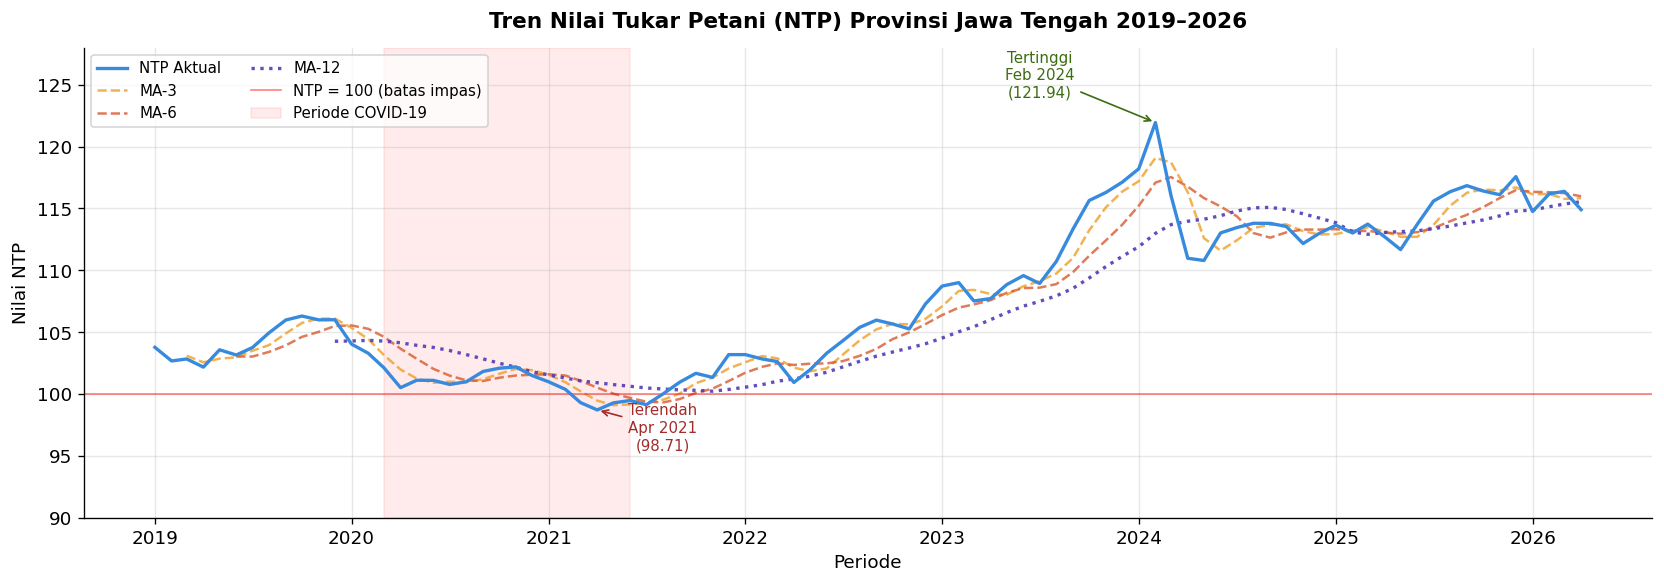

Plot disimpan: 01_tren_ntp.png


In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df.index, df['NTP'], color='#378ADD', linewidth=2, label='NTP Aktual', zorder=3)
ax.plot(df.index, df['MA_3'], color='#EF9F27', linewidth=1.5, linestyle='--', label='MA-3', alpha=0.8)
ax.plot(df.index, df['MA_6'], color='#D85A30', linewidth=1.5, linestyle='--', label='MA-6', alpha=0.8)
ax.plot(df.index, df['MA_12'], color='#533AB7', linewidth=2, linestyle=':', label='MA-12', alpha=0.9)

ax.axhline(y=100, color='red', linewidth=1, linestyle='-', alpha=0.5, label='NTP = 100 (batas impas)')

ax.annotate('Terendah\nApr 2021\n(98.71)',
            xy=(pd.Timestamp('2021-04-01'), 98.71),
            xytext=(pd.Timestamp('2021-08-01'), 95.5),
            arrowprops=dict(arrowstyle='->', color='#A32D2D'),
            color='#A32D2D', fontsize=9, ha='center')

ax.annotate('Tertinggi\nFeb 2024\n(121.94)',
            xy=(pd.Timestamp('2024-02-01'), 121.94),
            xytext=(pd.Timestamp('2023-07-01'), 124),
            arrowprops=dict(arrowstyle='->', color='#3B6D11'),
            color='#3B6D11', fontsize=9, ha='center')

ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'),
           alpha=0.08, color='red', label='Periode COVID-19')

ax.set_title('Tren Nilai Tukar Petani (NTP) Provinsi Jawa Tengah 2019–2026',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Periode')
ax.set_ylabel('Nilai NTP')
ax.set_ylim(90, 128)
ax.legend(loc='upper left', fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig('01_tren_ntp.png', bbox_inches='tight')
plt.show()
print('Plot disimpan: 01_tren_ntp.png')

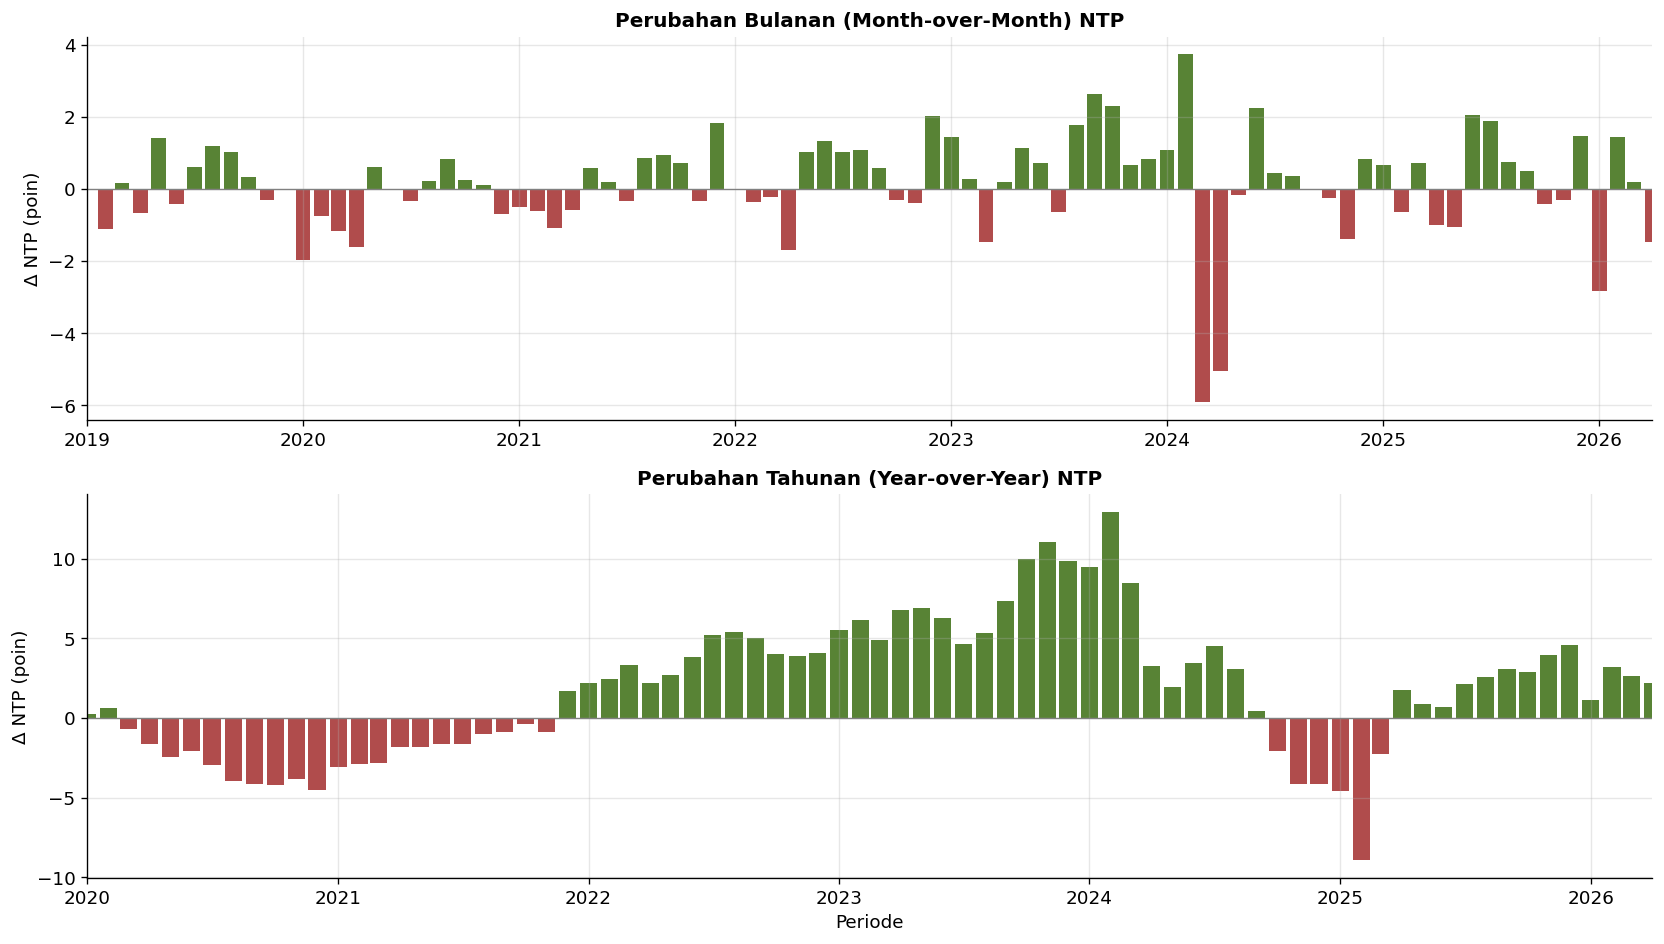

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

# MoM
colors_mom = ['#3B6D11' if v >= 0 else '#A32D2D' for v in df['MoM'].dropna()]
ax1.bar(df.index[1:], df['MoM'].dropna(), color=colors_mom, width=25, alpha=0.85)
ax1.axhline(0, color='gray', linewidth=0.8)
ax1.set_title('Perubahan Bulanan (Month-over-Month) NTP', fontsize=12, fontweight='bold')
ax1.set_ylabel('Δ NTP (poin)')
ax1.set_xlim(df.index[0], df.index[-1])

# YoY
yoy_data = df['YoY'].dropna()
colors_yoy = ['#3B6D11' if v >= 0 else '#A32D2D' for v in yoy_data]
ax2.bar(yoy_data.index, yoy_data, color=colors_yoy, width=25, alpha=0.85)
ax2.axhline(0, color='gray', linewidth=0.8)
ax2.set_title('Perubahan Tahunan (Year-over-Year) NTP', fontsize=12, fontweight='bold')
ax2.set_ylabel('Δ NTP (poin)')
ax2.set_xlabel('Periode')
ax2.set_xlim(yoy_data.index[0], df.index[-1])

plt.tight_layout()
plt.show()

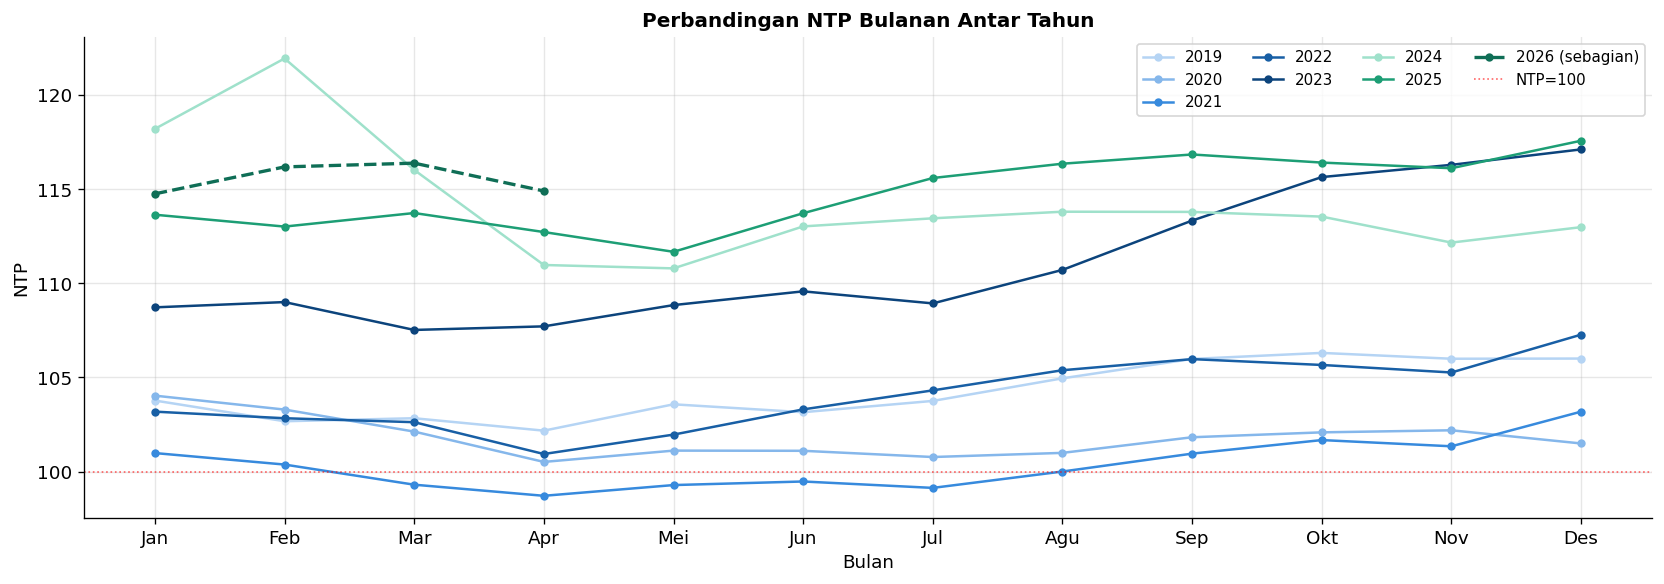

In [ ]:
df_seasonal = df.copy()
df_seasonal['Tahun'] = df_seasonal.index.year
df_seasonal['Bulan_ke'] = df_seasonal.index.month

nama_bulan = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'Mei', 6: 'Jun',
    7: 'Jul', 8: 'Agu', 9: 'Sep', 10: 'Okt', 11: 'Nov', 12: 'Des'
}

fig, ax = plt.subplots(figsize=(14, 5))

palette = ['#B5D4F4','#85B7EB','#378ADD','#185FA5','#0C447C','#9FE1CB','#1D9E75','#0F6E56']
years = sorted(df_seasonal['Tahun'].unique())

for i, yr in enumerate(years):
    data_yr = df_seasonal[df_seasonal['Tahun']==yr]
    style = '-' if yr < 2026 else '--'
    lw = 1.5 if yr < 2026 else 2
    label = str(yr) if yr < 2026 else f'{yr} (sebagian)'
    ax.plot(data_yr['Bulan_ke'], data_yr['NTP'],
            color=palette[i % len(palette)], linewidth=lw,
            linestyle=style, marker='o', markersize=4, label=label)

ax.axhline(100, color='red', linewidth=1, linestyle=':', alpha=0.6, label='NTP=100')
ax.set_xticks(range(1,13))
ax.set_xticklabels([nama_bulan[i] for i in range(1,13)])
ax.set_title('Perbandingan NTP Bulanan Antar Tahun', fontsize=12, fontweight='bold')
ax.set_ylabel('NTP')
ax.set_xlabel('Bulan')
ax.legend(ncol=4, fontsize=9)

plt.tight_layout()
plt.show()

# Uji Stasioneritas & Dekomposisi

uji kelayakan data jika P-Val <0,05 dinyatakan stasioner danlayak dilakukan analisis lanjutan

In [ ]:
def adf_test(series, name=''):
    result = adfuller(series.dropna())
    print(f'=== ADF Test: {name} ===')
    print(f'ADF Statistic : {result[0]:.4f}')
    print(f'p-value       : {result[1]:.4f}')
    print(f'Critical Values:')
    for k, v in result[4].items():
        print(f'   {k}: {v:.4f}')
    if result[1] <= 0.05:
        print('→ Data STASIONER (tolak H0)')
    else:
        print('→ Data TIDAK stasioner (gagal tolak H0)')
    print()

adf_test(df['NTP'], 'NTP Level')
adf_test(df['NTP'].diff().dropna(), 'NTP First Difference')

=== ADF Test: NTP Level ===
ADF Statistic : -0.8513
p-value       : 0.8036
Critical Values:
   1%: -3.5097
   5%: -2.8962
   10%: -2.5853
→ Data TIDAK stasioner (gagal tolak H0)

=== ADF Test: NTP First Difference ===
ADF Statistic : -7.0725
p-value       : 0.0000
Critical Values:
   1%: -3.5097
   5%: -2.8962
   10%: -2.5853
→ Data STASIONER (tolak H0)



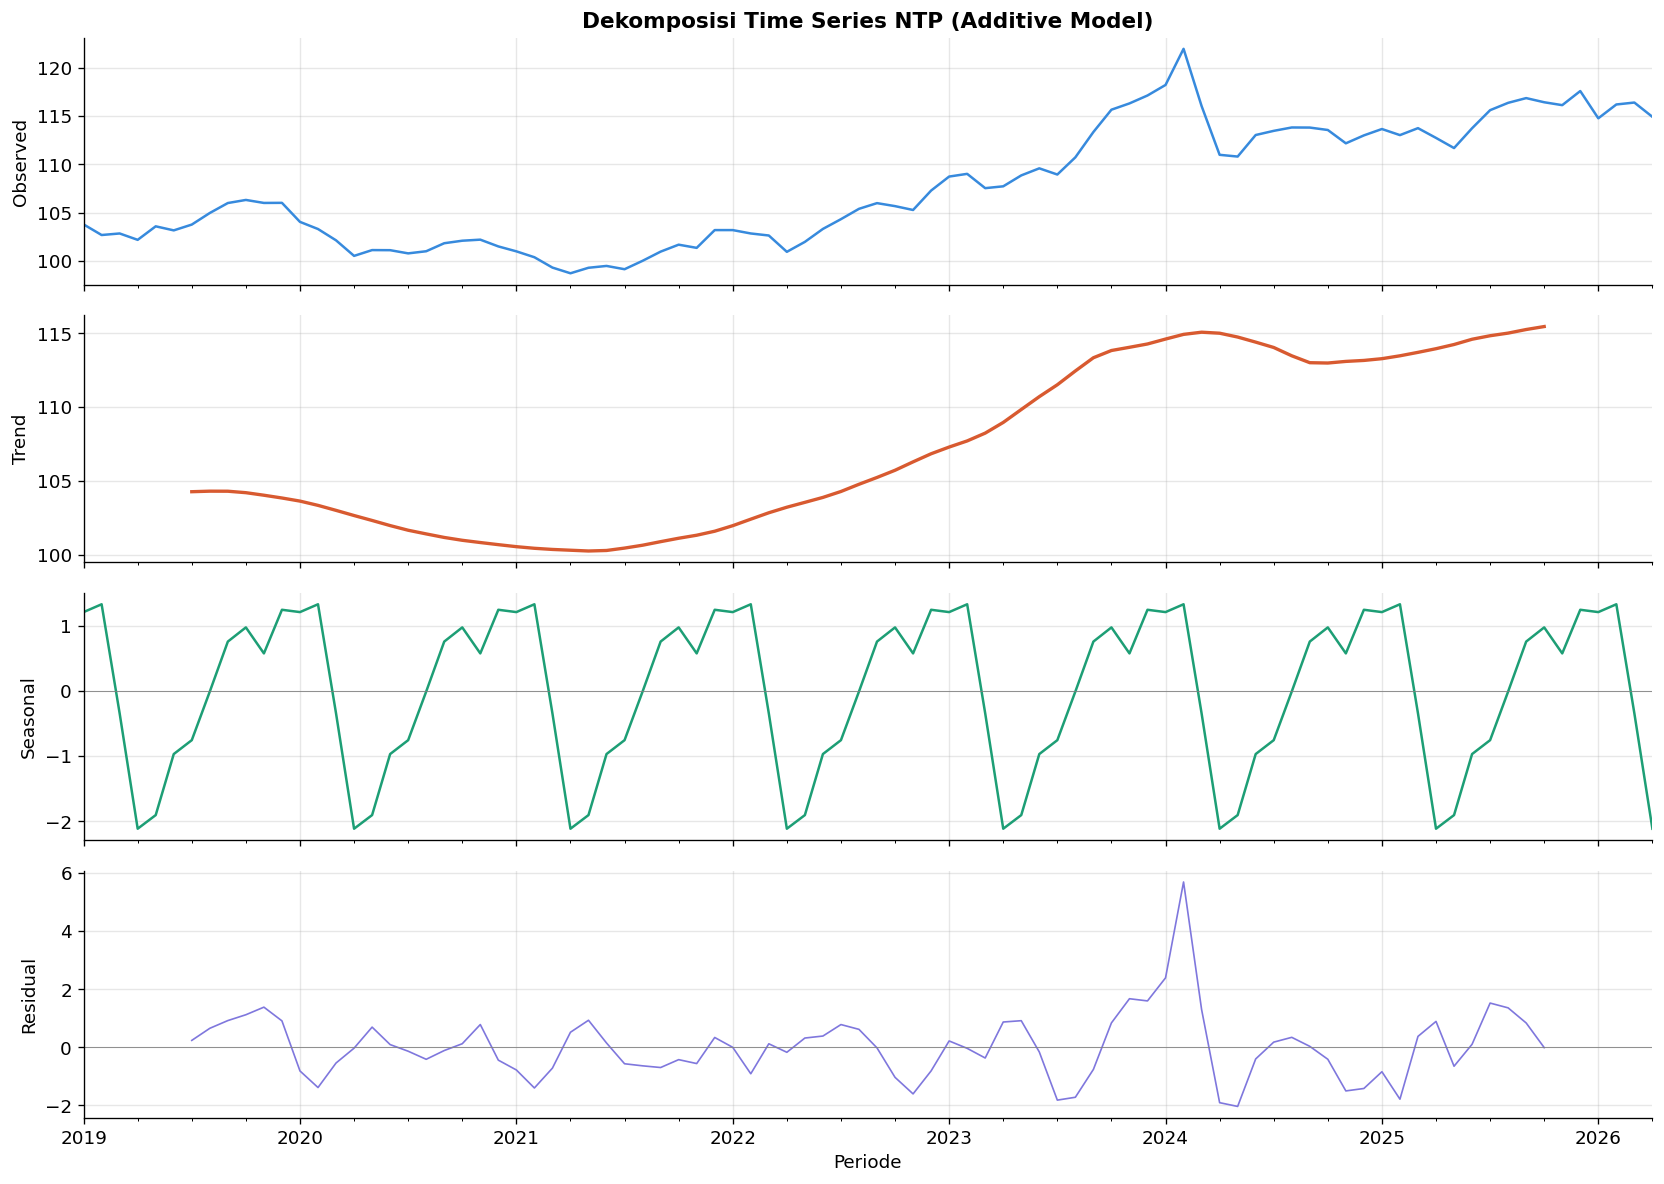

In [ ]:
# Dekomposisi time series
decomp = seasonal_decompose(df['NTP'], model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

decomp.observed.plot(ax=axes[0], color='#378ADD', linewidth=1.5)
axes[0].set_ylabel('Observed')
axes[0].set_title('Dekomposisi Time Series NTP (Additive Model)', fontsize=13, fontweight='bold')

decomp.trend.plot(ax=axes[1], color='#D85A30', linewidth=2)
axes[1].set_ylabel('Trend')

decomp.seasonal.plot(ax=axes[2], color='#1D9E75', linewidth=1.5)
axes[2].set_ylabel('Seasonal')
axes[2].axhline(0, color='gray', linewidth=0.5)

decomp.resid.plot(ax=axes[3], color='#7F77DD', linewidth=1)
axes[3].set_ylabel('Residual')
axes[3].axhline(0, color='gray', linewidth=0.5)
axes[3].set_xlabel('Periode')

for ax in axes:
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

---
# Forecasting

Tiga metode yang dibandingkan:
1. **Moving Average (MA-12)** — baseline sederhana
2. **Holt-Winters (Triple Exponential Smoothing)** — menangkap tren + musiman
3. **SARIMA**

# Split Data

In [ ]:
# Split data: train (80%) & test (20%)
n = len(df)
split_idx = int(n * 0.8)
train = df['NTP'].iloc[:split_idx]
test  = df['NTP'].iloc[split_idx:]

print(f'Train: {len(train)} bulan ({train.index[0].strftime("%b %Y")} – {train.index[-1].strftime("%b %Y")})')
print(f'Test : {len(test)} bulan ({test.index[0].strftime("%b %Y")} – {test.index[-1].strftime("%b %Y")})')

Train: 70 bulan (Jan 2019 – Oct 2024)
Test : 18 bulan (Nov 2024 – Apr 2026)


# Moving Average (MA-12)

In [ ]:
# MA-12: forecast = rata-rata 12 bulan terakhir
ma6_preds = []
history = list(train)
for i in range(len(test)):
    pred = np.mean(history[-12:])
    ma6_preds.append(pred)
    history.append(test.iloc[i])

ma6_series = pd.Series(ma6_preds, index=test.index)

mae_ma6  = mean_absolute_error(test, ma6_preds)
rmse_ma6 = np.sqrt(mean_squared_error(test, ma6_preds))
mape_ma6 = np.mean(np.abs((test.values - np.array(ma6_preds)) / test.values)) * 100

print(f'MA-6  | MAE: {mae_ma6:.3f} | RMSE: {rmse_ma6:.3f} | MAPE: {mape_ma6:.3f}%')

MA-6  | MAE: 1.558 | RMSE: 1.879 | MAPE: 1.351%


# Holt-Winters (Triple Exponential Smoothing)

In [ ]:
hw_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit(optimized=True)

hw_preds = hw_model.forecast(len(test))
hw_preds.index = test.index

mae_hw  = mean_absolute_error(test, hw_preds)
rmse_hw = np.sqrt(mean_squared_error(test, hw_preds))
mape_hw = np.mean(np.abs((test.values - hw_preds.values) / test.values)) * 100

print(f'Holt-Winters | MAE: {mae_hw:.3f} | RMSE: {rmse_hw:.3f} | MAPE: {mape_hw:.3f}%')
print(f'Parameter    | alpha={hw_model.params["smoothing_level"]:.3f}, '
      f'beta={hw_model.params["smoothing_trend"]:.3f}, '
      f'gamma={hw_model.params["smoothing_seasonal"]:.3f}')

Holt-Winters | MAE: 1.345 | RMSE: 1.501 | MAPE: 1.169%
Parameter    | alpha=1.000, beta=0.000, gamma=0.000


# SARIMA

In [ ]:
# auto_arima: cari order SARIMA terbaik secara otomatis
from pmdarima import auto_arima

sarima_auto = auto_arima(
    train,
    seasonal=True,
    m=12,
    start_p=0,
    start_q=0,
    max_p=3,
    max_q=3,
    max_P=2,
    max_Q=2,
    max_d=2,
    max_D=1,
    trace=True,
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore'
)

print(sarima_auto.summary())

print('Best SARIMA order  :', sarima_auto.order)
print('Seasonal order     :', sarima_auto.seasonal_order)
print()
print(sarima_auto.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=244.346, Time=0.59 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=249.028, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=242.541, Time=0.13 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=242.334, Time=0.10 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=247.702, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=244.296, Time=0.04 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : AIC=240.189, Time=0.28 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : AIC=240.058, Time=0.09 sec
 ARIMA(0,1,1)(2,0,0)[12] intercept   : AIC=240.001, Time=0.33 sec
 ARIMA(0,1,1)(2,0,1)[12] intercept   : AIC=241.904, Time=0.45 sec
 ARIMA(0,1,0)(2,0,0)[12] intercept   : AIC=243.821, Time=0.28 sec
 ARIMA(1,1,1)(2,0,0)[12] intercept   : AIC=241.749, Time=0.46 sec
 ARIMA(0,1,2)(2,0,0)[12] intercept   : AIC=241.402, Time=0.38 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=242.079, Time=0.38 sec
 ARIMA(1,1,2)(2,0,0)[12] intercep

In [ ]:
best_order = sarima_auto.order
best_seasonal = sarima_auto.seasonal_order

print("Order:", best_order)
print("Seasonal:", best_seasonal)

Order: (0, 1, 1)
Seasonal: (2, 0, 0, 12)


In [ ]:
sarima_preds = pd.Series(
    sarima_auto.predict(n_periods=len(test)),
    index=test.index
)

mae_sa  = mean_absolute_error(test, sarima_preds)
rmse_sa = np.sqrt(mean_squared_error(test, sarima_preds))
mape_sa = np.mean(np.abs((test.values - sarima_preds.values) / test.values)) * 100

print(f'SARIMA | MAE: {mae_sa:.3f} | RMSE: {rmse_sa:.3f} | MAPE: {mape_sa:.3f}%')

SARIMA | MAE: 1.330 | RMSE: 1.521 | MAPE: 1.157%


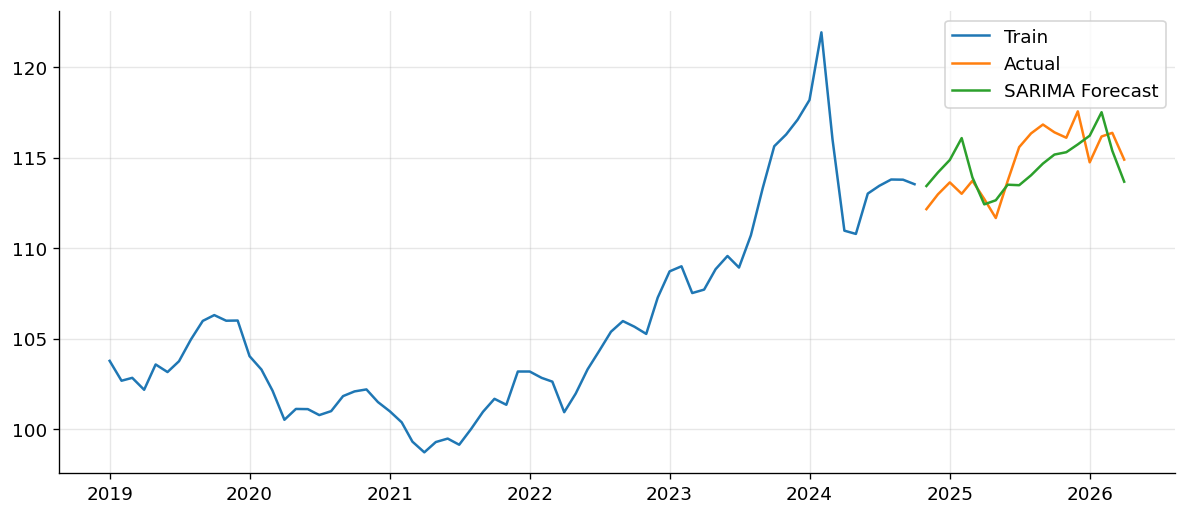

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, sarima_preds, label='SARIMA Forecast')

plt.legend()
plt.show()

# Perbandingan Performa Model

In [ ]:
results = pd.DataFrame({
    'Model': ['Moving Average (MA-6)', 'Holt-Winters', 'SARIMA (auto)'],
    'MAE'  : [mae_ma6,  mae_hw,  mae_sa],
    'RMSE' : [rmse_ma6, rmse_hw, rmse_sa],
    'MAPE (%)': [mape_ma6, mape_hw, mape_sa]
}).round(3)

print('=== Perbandingan Performa Model ===')
print(results.to_string(index=False))
best = results.loc[results['MAPE (%)'].idxmin(), 'Model']
print(f'\n→ Model terbaik berdasarkan MAPE: {best}')

=== Perbandingan Performa Model ===
                Model   MAE  RMSE  MAPE (%)
Moving Average (MA-6) 1.558 1.879     1.351
         Holt-Winters 1.345 1.501     1.169
        SARIMA (auto) 1.330 1.521     1.157

→ Model terbaik berdasarkan MAPE: SARIMA (auto)


# Visualisasi Forecast per Model

Tiap model ditampilkan dalam subplot tersendiri agar mudah dibandingkan secara visual.

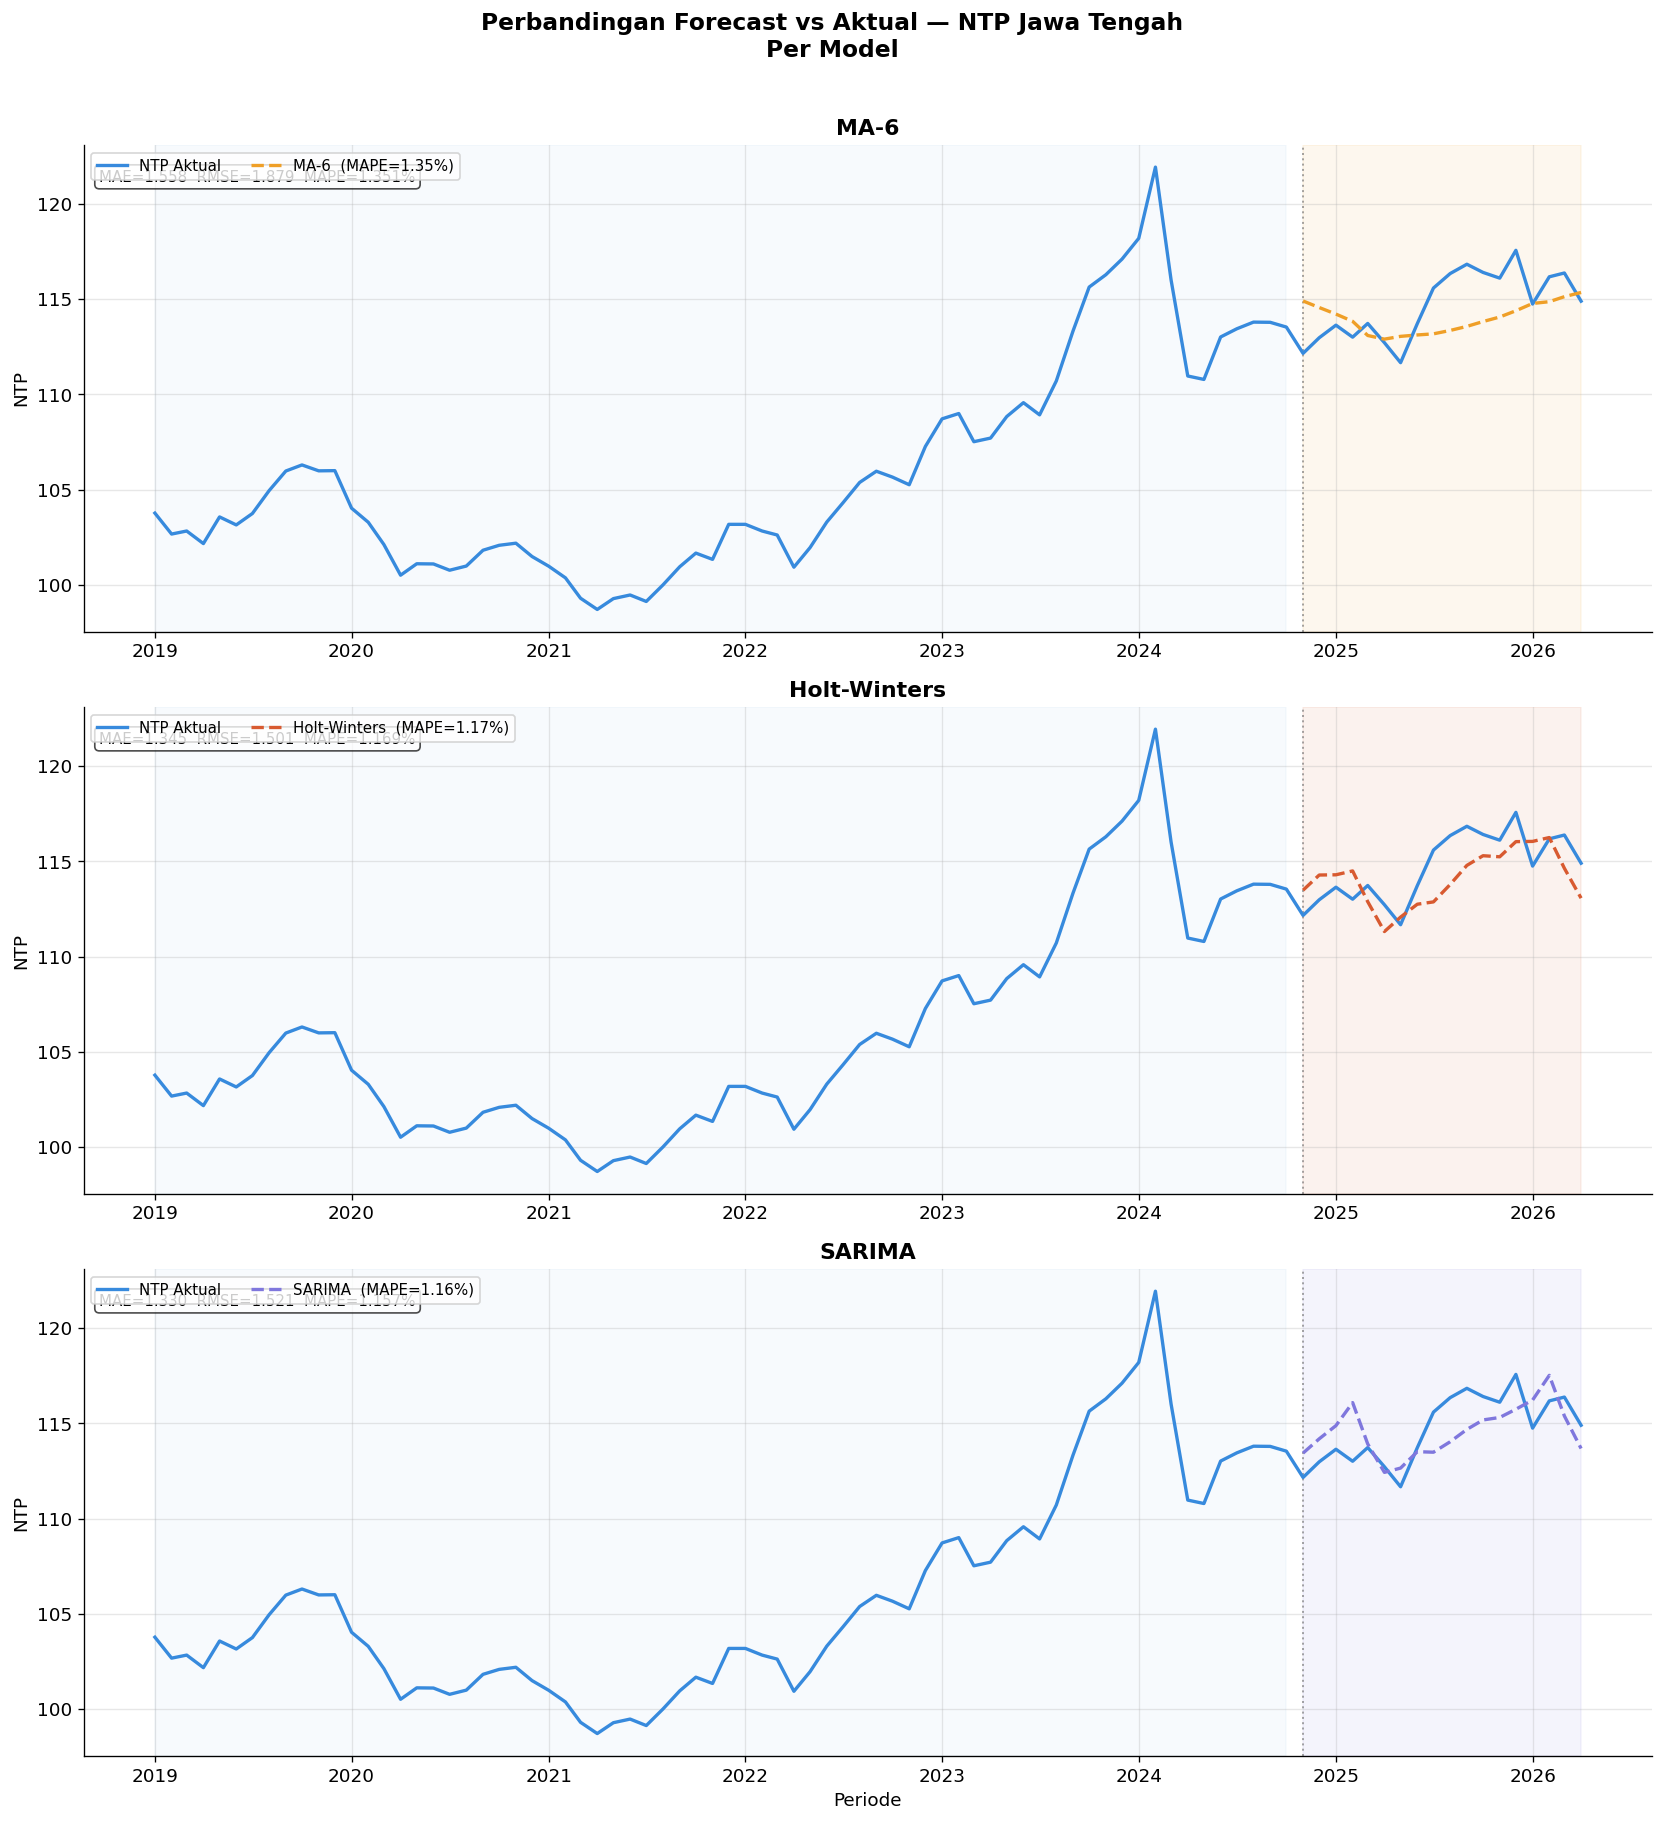

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 15), sharex=False)
fig.suptitle('Perbandingan Forecast vs Aktual — NTP Jawa Tengah\nPer Model',
             fontsize=14, fontweight='bold', y=1.01)

configs = [
    (ma6_series,   '#EF9F27', f'MA-6  (MAPE={mape_ma6:.2f}%)',         mae_ma6,  rmse_ma6,  mape_ma6),
    (hw_preds,     '#D85A30', f'Holt-Winters  (MAPE={mape_hw:.2f}%)',  mae_hw,   rmse_hw,   mape_hw),
    (sarima_preds, '#7F77DD', f'SARIMA  (MAPE={mape_sa:.2f}%)',        mae_sa,   rmse_sa,   mape_sa),
]

for ax, (preds, color, label, mae, rmse, mape) in zip(axes, configs):
    # Aktual full
    ax.plot(df['NTP'], color='#378ADD', linewidth=2, label='NTP Aktual', zorder=3)
    # Prediksi di periode test
    ax.plot(preds, color=color, linewidth=2, linestyle='--', label=label, zorder=4)
    # Shading train vs test
    ax.axvspan(train.index[0], train.index[-1], alpha=0.04, color='#378ADD')
    ax.axvspan(test.index[0],  test.index[-1],  alpha=0.08, color=color)
    ax.axvline(test.index[0], color='gray', linestyle=':', linewidth=1.2, alpha=0.7)
    # Annotasi metrik
    ax.text(0.01, 0.95,
            f'MAE={mae:.3f}  RMSE={rmse:.3f}  MAPE={mape:.3f}%',
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
    ax.set_ylabel('NTP')
    ax.legend(fontsize=9, loc='upper left', ncol=2)
    ax.set_title(label.split('(')[0].strip(), fontweight='bold')

axes[-1].set_xlabel('Periode')
plt.tight_layout()
plt.show()

### 5.6 Visualisasi Gabungan — Semua Model vs Aktual

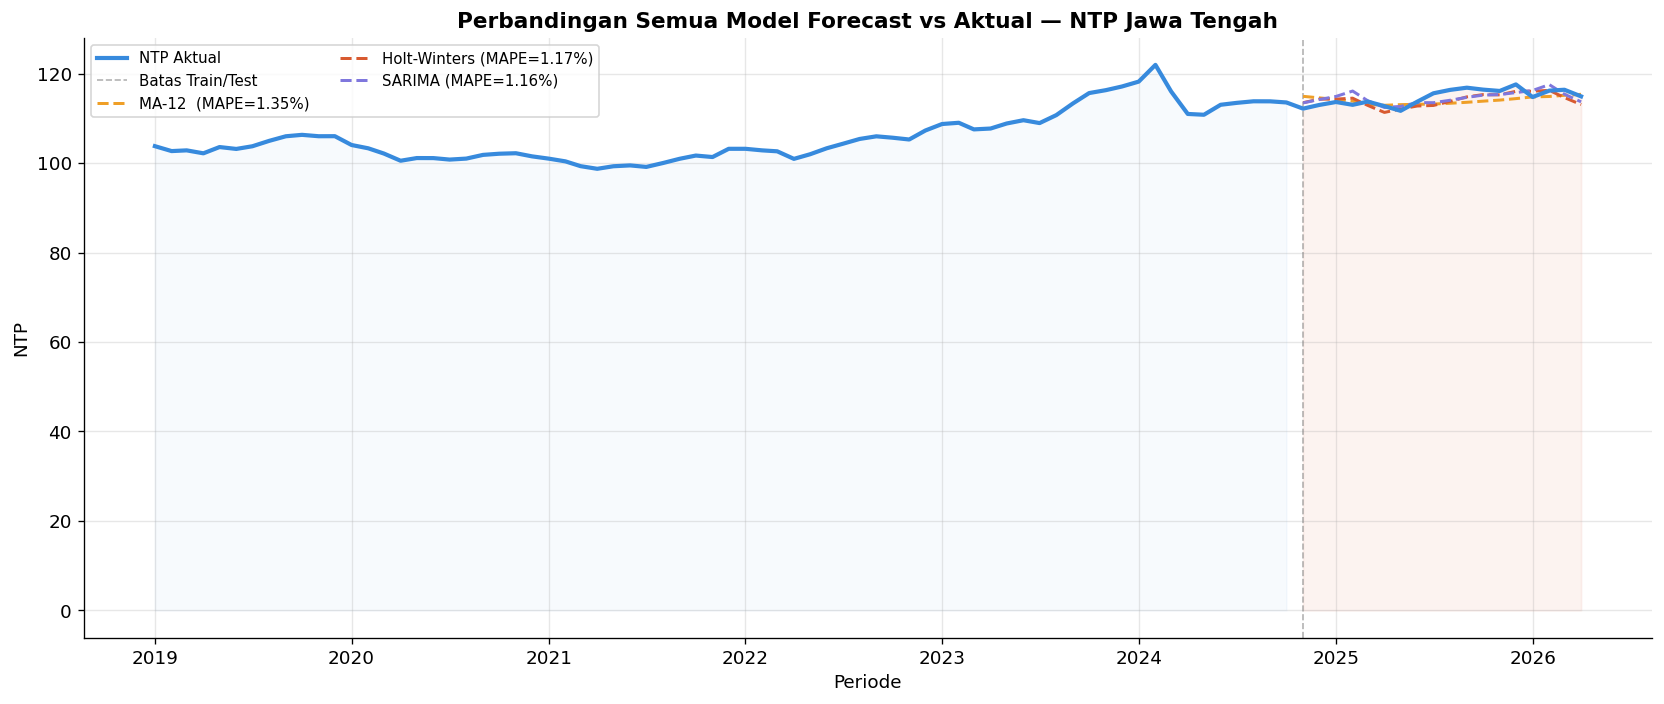

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df['NTP'], color='#378ADD', linewidth=2.5, label='NTP Aktual', zorder=5)
ax.axvline(test.index[0], color='gray', linestyle='--', linewidth=1, alpha=0.6, label='Batas Train/Test')

ax.plot(ma6_series,   color='#EF9F27', linewidth=1.8, linestyle='--', label=f'MA-12  (MAPE={mape_ma6:.2f}%)')
ax.plot(hw_preds,     color='#D85A30', linewidth=1.8, linestyle='--', label=f'Holt-Winters (MAPE={mape_hw:.2f}%)')
ax.plot(sarima_preds, color='#7F77DD', linewidth=1.8, linestyle='--', label=f'SARIMA (MAPE={mape_sa:.2f}%)')

ax.fill_between(train.index, train, alpha=0.04, color='#378ADD')
ax.fill_between(test.index,  test,  alpha=0.07, color='#D85A30')

ax.set_title('Perbandingan Semua Model Forecast vs Aktual — NTP Jawa Tengah',
             fontsize=13, fontweight='bold')
ax.set_ylabel('NTP')
ax.set_xlabel('Periode')
ax.legend(fontsize=9, ncol=2)

plt.tight_layout()
plt.show()

# Proyeksi Mei–Desember 2027 — Semua Model

Ketiga model dilatih ulang dengan **seluruh data** lalu memproyeksikan 20 bulan ke depan.  
Confidence interval 95% menggunakan `± 1.96 × RMSE` masing-masing model.

In [ ]:
n_forecast = 20  # Mei–Des 2026
last_date  = df.index[-1]
fc_index   = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=n_forecast, freq='MS')

# MA-12
history_full = list(df['NTP'])
ma6_fc = []
for _ in range(n_forecast):
    pred = np.mean(history_full[-12:])
    ma6_fc.append(pred)
    history_full.append(pred)
ma6_fc = pd.Series(ma6_fc, index=fc_index)

# Holt-Winters
hw_full = ExponentialSmoothing(
    df['NTP'], trend='add', seasonal='add', seasonal_periods=12
).fit(optimized=True)
hw_fc = hw_full.forecast(n_forecast)
hw_fc.index = fc_index

# SARIMA
sarima_full = auto_arima(
    df['NTP'], seasonal=True, m=12, stepwise=True,
    suppress_warnings=True, error_action='ignore'
)
sarima_fc = pd.Series(sarima_full.predict(n_periods=n_forecast), index=fc_index)

# Tabel proyeksi
fc_df = pd.DataFrame({
    'Periode'     : fc_index.strftime('%b %Y'),
    'MA-6'        : ma6_fc.round(2).values,
    'Holt-Winters': hw_fc.round(2).values,
    'SARIMA'      : sarima_fc.round(2).values,
})
print('=== Proyeksi NTP Mei–Desember 2026 ===')
print(fc_df.to_string(index=False))

=== Proyeksi NTP Mei–Desember 2026 ===
 Periode   MA-6  Holt-Winters  SARIMA
May 2026 115.54        115.40  114.92
Jun 2026 115.86        116.27  115.72
Jul 2026 116.04        116.64  116.08
Aug 2026 116.08        117.54  116.59
Sep 2026 116.05        118.47  117.08
Oct 2026 115.99        118.84  117.23
Nov 2026 115.95        118.56  117.02
Dec 2026 115.94        119.45  117.65
Jan 2027 115.81        119.15  117.36
Feb 2027 115.89        119.41  117.78
Mar 2027 115.87        118.31  117.18
Apr 2027 115.83        116.82  116.19
May 2027 115.90        117.32  116.26
Jun 2027 115.94        118.20  116.95
Jul 2027 115.94        118.57  117.28
Aug 2027 115.93        119.46  117.74
Sep 2027 115.92        120.39  118.18
Oct 2027 115.91        120.76  118.31
Nov 2027 115.90        120.48  118.12
Dec 2027 115.90        121.38  118.69


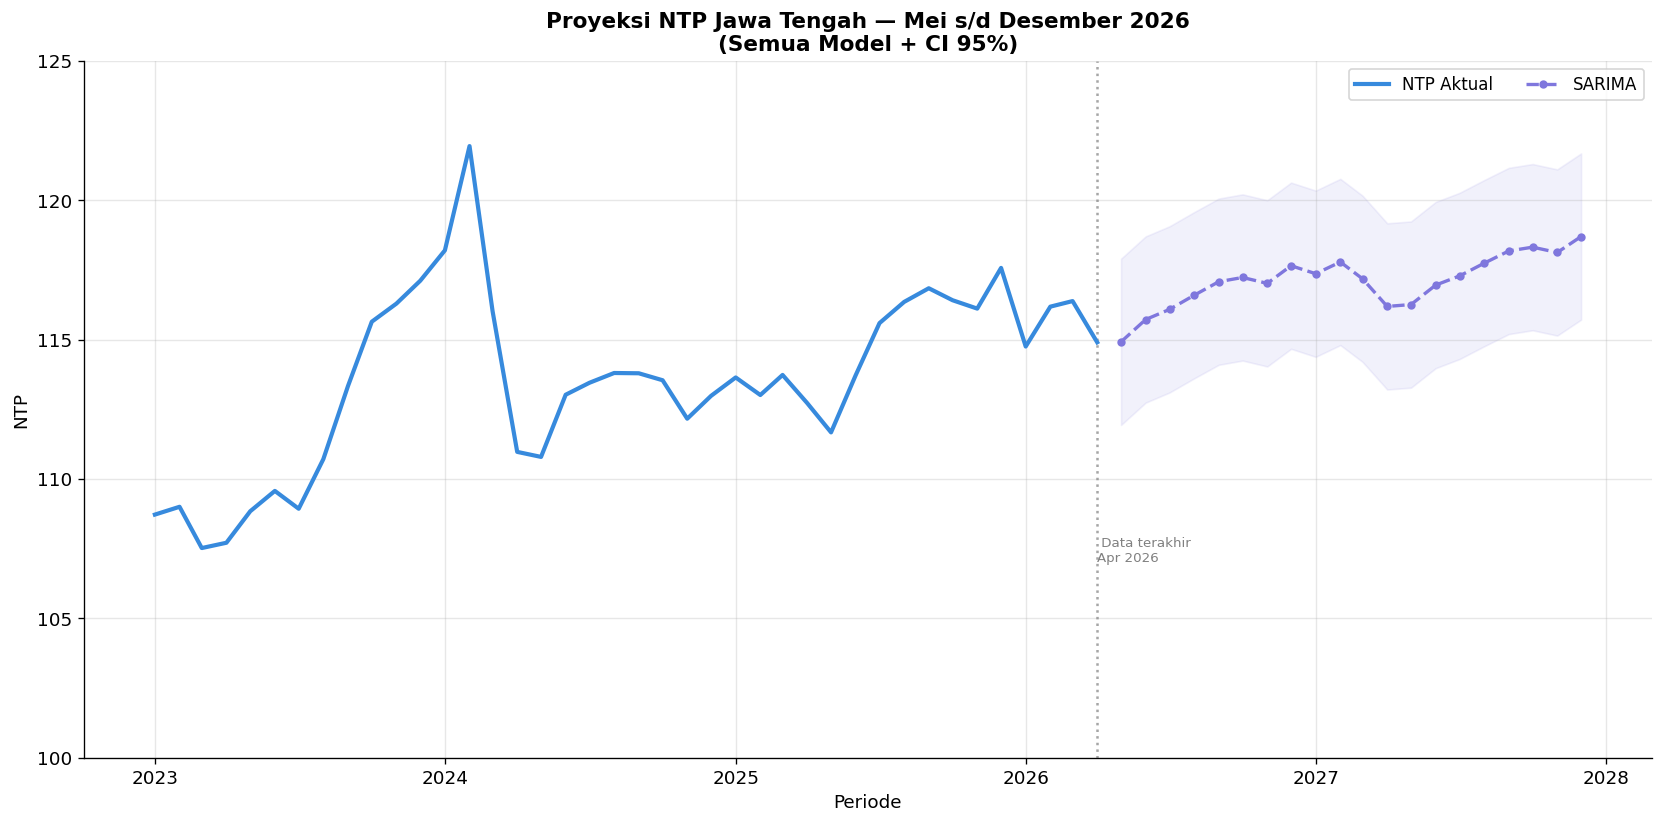

Plot disimpan: proyeksi_2026_semua_model.png


In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))

# Historis 2 tahun terakhir
recent = df['NTP'].loc['2023':]
ax.plot(recent, color='#378ADD', linewidth=2.5, label='NTP Aktual', zorder=5)
ax.axvline(df.index[-1], color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
ax.text(df.index[-1], recent.min()-0.5, ' Data terakhir\nApr 2026', color='gray', fontsize=8)

# Forecast + CI per model
for fc_vals, color, label, rmse in [

    (sarima_fc, '#7F77DD', 'SARIMA',       rmse_sa),
]:
    ci_upper = fc_vals + 1.96 * rmse
    ci_lower = fc_vals - 1.96 * rmse
    ax.plot(fc_vals, color=color, linewidth=2, linestyle='--', marker='o', markersize=4, label=label)
    ax.fill_between(fc_index, ci_lower, ci_upper, color=color, alpha=0.10)

ax.set_title('Proyeksi NTP Jawa Tengah — Mei s/d Desember 2026\n(Semua Model + CI 95%)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('NTP')
ax.set_xlabel('Periode')
ax.set_ylim(100, 125)
ax.legend(fontsize=10, ncol=2)

plt.tight_layout()
plt.savefig('proyeksi_2026_semua_model.png', bbox_inches='tight', dpi=150)
plt.show()
print('Plot disimpan: proyeksi_2026_semua_model.png')

---
## 6. Ringkasan Insight & Kesimpulan

In [ ]:
print('='*60)
print('RINGKASAN ANALISIS NTP PROVINSI JAWA TENGAH 2019–2026')
print('='*60)

best_model = min(
    [('MA-6', mape_ma6), ('Holt-Winters', mape_hw), ('SARIMA', mape_sa)],
    key=lambda x: x[1]
)[0]

print(f"""
1. TREN KESELURUHAN
   NTP naik dari {df['NTP'].iloc[0]:.2f} (Jan 2019) → {df['NTP'].iloc[-1]:.2f} (Apr 2026)
   Kenaikan total: +{df['NTP'].iloc[-1]-df['NTP'].iloc[0]:.2f} poin ({(df['NTP'].iloc[-1]/df['NTP'].iloc[0]-1)*100:.1f}%)

2. PERIODE KRITIS
   Terendah : {df['NTP'].idxmin().strftime('%b %Y')} = {df['NTP'].min():.2f} (< 100 → petani merugi)
   Tertinggi: {df['NTP'].idxmax().strftime('%b %Y')} = {df['NTP'].max():.2f}

3. PERFORMA MODEL FORECASTING
   MA-6         → MAPE: {mape_ma6:.3f}%
   Holt-Winters → MAPE: {mape_hw:.3f}%
   SARIMA       → MAPE: {mape_sa:.3f}%
   Model terbaik (MAPE terendah): {best_model}

4. PROYEKSI (Mei 2026 – Des 2027)
   Kisaran forecast: {fc_vals.min():.2f} – {fc_vals.max():.2f}
   Rata-rata proyeksi: {fc_vals.mean():.2f}
   → NTP diperkirakan STABIL di atas 100 sepanjang 2026-2027 akhir

5. KESIMPULAN
   Kesejahteraan petani Jawa Tengah menunjukkan tren membaik
   dalam jangka panjang, namun rentan terhadap guncangan
   eksternal (pandemi, inflasi, koreksi harga panen raya).
   SARIMA unggul secara statistik karena menangkap pola
   musiman 12 bulan yang tidak bisa ditangkap ARIMA biasa.
""")
print('='*60)

RINGKASAN ANALISIS NTP PROVINSI JAWA TENGAH 2019–2026

1. TREN KESELURUHAN
   NTP naik dari 103.77 (Jan 2019) → 114.90 (Apr 2026)
   Kenaikan total: +11.13 poin (10.7%)

2. PERIODE KRITIS
   Terendah : Apr 2021 = 98.71 (< 100 → petani merugi)
   Tertinggi: Feb 2024 = 121.94

3. PERFORMA MODEL FORECASTING
   MA-6         → MAPE: 1.351%
   Holt-Winters → MAPE: 1.169%
   SARIMA       → MAPE: 1.157%
   Model terbaik (MAPE terendah): SARIMA

4. PROYEKSI 2026 (Mei–Des)
   Kisaran forecast: 114.92 – 118.69
   Rata-rata proyeksi: 117.12
   → NTP diperkirakan STABIL di atas 100 sepanjang 2026

5. KESIMPULAN
   Kesejahteraan petani Jawa Tengah menunjukkan tren membaik
   dalam jangka panjang, namun rentan terhadap guncangan
   eksternal (pandemi, inflasi, koreksi harga panen raya).
   SARIMA unggul secara statistik karena menangkap pola
   musiman 12 bulan yang tidak bisa ditangkap ARIMA biasa.



Perbandingan 3 Model yang dilakukan untuk forecasting bertujuan untuk menentukan dengan model apa dataset menghasilkan hasil prediksi terbaik. dan ari hasil analisis diatas model SARIMA ditetapkan menjadi model terbaik karana memiliki nilai MAPE paling rendah, karena semakin rendah nilai MAPE artinya semakin kecil terjadinya kesalahan prediksi. sekiannnn